# Import

In [39]:
import os
from glob import glob
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random
from torch.utils.data import Dataset, DataLoader
import torch
from torch import nn
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.model_selection import KFold
import seaborn as sns
import torch.optim as optim
from tqdm import tqdm
import torchvision.models as models
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Explore

In [40]:
print(os.getcwd())

/home/nguyenhl/workspace/medtech


In [41]:
main_dir = os.getcwd()
print(main_dir)
data_dir = main_dir + '/HAM10000_images_part_*/*'
data_list = glob(data_dir)
print(f'Total number of images: {len(data_list)}')

/home/nguyenhl/workspace/medtech
Total number of images: 10015


In [42]:
img_dict = {
    os.path.basename(p).replace(".jpg", ""): p
    for p in data_list}

In [43]:
lesion_type_dict = {
    'nv':'Melanocytic Nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'}

In [44]:
skin_df = pd.read_csv(main_dir +'/HAM10000_metadata')
skin_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


In [45]:
skin_df['cell_type'] = skin_df['dx'].map(lesion_type_dict.get)
skin_df['cell_type_idx'] = pd.Categorical(skin_df['cell_type']).codes
skin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   lesion_id      10015 non-null  object 
 1   image_id       10015 non-null  object 
 2   dx             10015 non-null  object 
 3   dx_type        10015 non-null  object 
 4   age            9958 non-null   float64
 5   sex            10015 non-null  object 
 6   localization   10015 non-null  object 
 7   dataset        10015 non-null  object 
 8   cell_type      10015 non-null  object 
 9   cell_type_idx  10015 non-null  int8   
dtypes: float64(1), int8(1), object(8)
memory usage: 714.1+ KB


In [46]:
skin_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,Benign keratosis-like lesions,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern,Benign keratosis-like lesions,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,Benign keratosis-like lesions,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,Benign keratosis-like lesions,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,Benign keratosis-like lesions,2


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


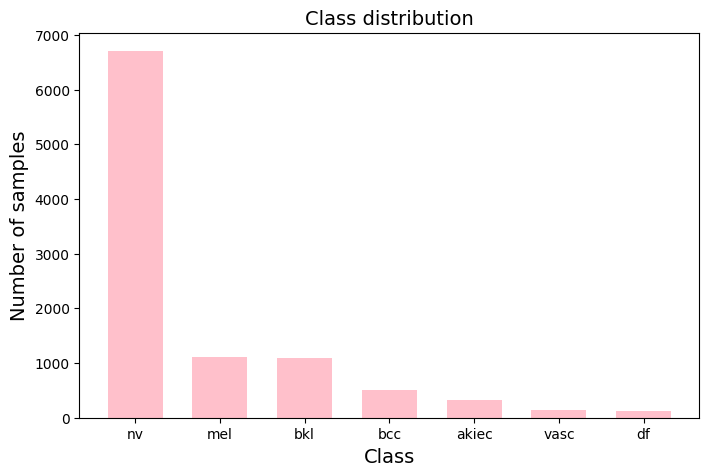

In [47]:
label_counts = skin_df['dx'].value_counts()
print(label_counts)
plt.figure(figsize=(8,5))
plt.bar(label_counts.index, label_counts.values, width=0.65, color='pink')  # smaller = thinner
# plt.gca().set_facecolor('#b08205')
plt.xlabel('Class', fontsize=14)
plt.ylabel('Number of samples', fontsize=14)
plt.title('Class distribution', fontsize=14)
plt.show()

In [48]:
label_counts = skin_df['cell_type_idx'].value_counts()
print(label_counts)

cell_type_idx
4    6705
5    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64


In [49]:
lesion_number_dict = {
    '4':'nv',
    '5': 'mel',
    '2': 'bkl',
    '1': 'bcc',
    '0': 'akiec',
    '3': 'vasc',
    '6': 'df'}
label_map = {int(k): v for k, v in lesion_number_dict.items()}
class_names = [label_map[i] for i in range(7)]
print(class_names)

['akiec', 'bcc', 'bkl', 'vasc', 'nv', 'mel', 'df']


In [50]:
# Count samples per class
class_counts = skin_df['cell_type_idx'].value_counts()
minority_classes = class_counts[class_counts < 600].index.tolist()
print("Minority classes:", minority_classes)

Minority classes: [1, 0, 6, 3]


Class weights:
nv: 0.6695
mel: 0.1111
bkl: 0.1097
bcc: 0.0513
akiec: 0.0327
vasc: 0.0142
df: 0.0115


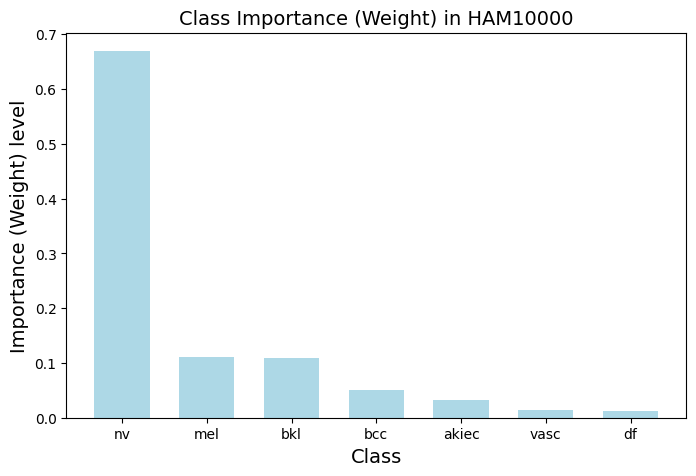

In [51]:
# plot the weighted class distribution
label_counts = skin_df['dx'].value_counts()
# weights = 1.0 / label_counts
# class_weights = weights / weights.sum() * len(label_counts)
class_weights = label_counts / label_counts.sum()
print("Class weights:")
for cls, weight in zip(label_counts.index, class_weights):
    print(f"{cls}: {weight:.4f}")
plt.figure(figsize=(8,5))
plt.bar(label_counts.index, class_weights[label_counts.index], width=0.65, color  ='lightblue')
plt.xlabel('Class', fontsize=14)
plt.ylabel('Importance (Weight) level', fontsize=14)
plt.title('Class Importance (Weight) in HAM10000', fontsize=14)
plt.show()

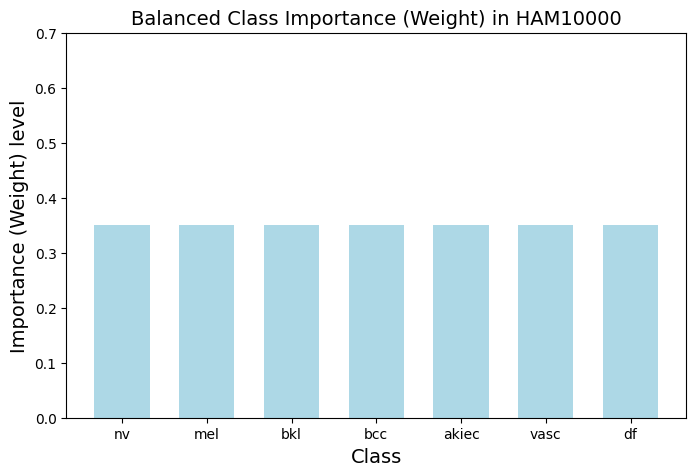

In [52]:
plt.figure(figsize=(8,5))
plt.bar(label_counts.index, [0.35]*7, width=0.65, color  ='lightblue')
plt.xlabel('Class', fontsize=14)
plt.ylabel('Importance (Weight) level', fontsize=14)
plt.title('Balanced Class Importance (Weight) in HAM10000', fontsize=14)
plt.ylim(0.0, 0.7)
plt.show()

In [53]:
classes = skin_df['dx'].unique()
print(classes)

['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']


In [54]:
img_dirs = [
    main_dir + "/HAM10000_images_part_1",
    main_dir + "/HAM10000_images_part_2"]

In [55]:
def find_image(image_id, img_dirs):
    for d in img_dirs:
        path = os.path.join(d, image_id + ".jpg")
        if os.path.exists(path):
            return path
    return None

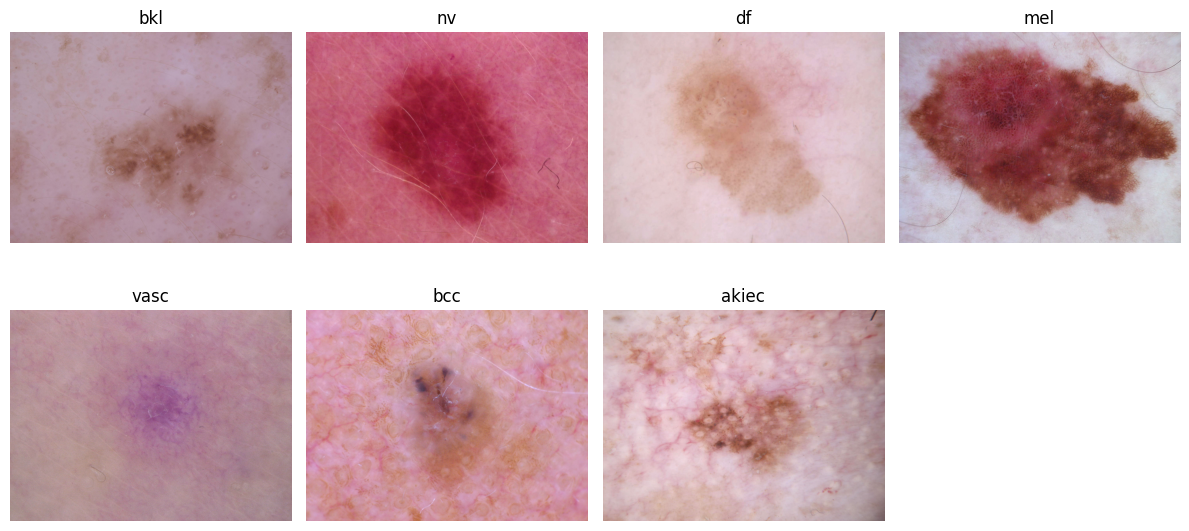

In [56]:
classes = skin_df['dx'].unique()

plt.figure(figsize=(12, 6))
i = 1
for cls in classes:
    row = skin_df[skin_df['dx'] == cls].sample(1).iloc[0]
    img_path = find_image(row['image_id'], img_dirs)


    if img_path is None:
        continue

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    save_path = os.path.join(main_dir, f"sample_{cls}.png")
    cv2.imwrite(save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    # print(img.shape)
    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
    i += 1
    # save image
    

plt.tight_layout()
plt.show()

# Preprocessing

In [57]:
# Split stratified by lesion and class
def split_by_lesion(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    lesions = df['lesion_id'].unique()
    lesion_dx = df.groupby('lesion_id')['dx'].first()
    
    from sklearn.model_selection import StratifiedShuffleSplit
    
    sss_test = StratifiedShuffleSplit(n_splits=1, test_size=test_ratio, random_state=42)
    for train_val_idx, test_idx in sss_test.split(lesions, lesion_dx):
        test_lesions = lesions[test_idx]
        train_val_lesions = lesions[train_val_idx]
    
    # Split train_val into train and val
    val_ratio_adjusted = val_ratio / (1 - test_ratio)
    sss_val = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio_adjusted, random_state=42)
    lesion_dx_train_val = lesion_dx.loc[train_val_lesions]
    for train_idx, val_idx in sss_val.split(train_val_lesions, lesion_dx_train_val):
        train_lesions = train_val_lesions[train_idx]
        val_lesions = train_val_lesions[val_idx]
    
    train_df = df[df['lesion_id'].isin(train_lesions)].reset_index(drop=True)
    val_df = df[df['lesion_id'].isin(val_lesions)].reset_index(drop=True)
    test_df = df[df['lesion_id'].isin(test_lesions)].reset_index(drop=True)
    
    return train_df, val_df, test_df

In [58]:
train_df, val_df, test_df = split_by_lesion(skin_df)
print(train_df.shape, val_df.shape, test_df.shape)

(7016, 10) (1503, 10) (1496, 10)


In [59]:
assert set(train_df.lesion_id).isdisjoint(val_df.lesion_id)
assert set(train_df.lesion_id).isdisjoint(test_df.lesion_id)
assert set(val_df.lesion_id).isdisjoint(test_df.lesion_id)

In [60]:
# Median sampling
class_counts = train_df['dx'].value_counts()
print(class_counts)

dx
nv       4685
mel       791
bkl       773
bcc       358
akiec     230
vasc      100
df         79
Name: count, dtype: int64


In [61]:
# median_count = int(class_counts.median())
# print("Median samples per class:", median_count)

In [62]:
# from sklearn.utils import resample
# df_train_med = []
# for cls, count in class_counts.items():
#     df_cls = train_df[train_df['dx'] == cls]
#     if count > median_count:
#         # downsample
#         df_cls_resampled = resample(
#             df_cls,
#             replace=False,
#             n_samples=median_count,
#             random_state=42
#         )
#     else:
#         # upsample
#         df_cls_resampled = resample(
#             df_cls,
#             replace=True,
#             n_samples=median_count,
#             random_state=42
#         )
#     df_train_med.append(df_cls_resampled)
# df_train_med = pd.concat(df_train_med).sample(frac=1, random_state=42).reset_index(drop=True)

In [63]:
# print(df_train_med['dx'].value_counts())

In [64]:
# print(df_train_med.shape, val_df.shape, test_df.shape)

# DataLoader

In [65]:
import random

class SkinData(Dataset):
    def __init__(self, df, img_dict, img_size=224, 
                 augment=False
                 ):
        self.df = df.reset_index(drop=True)
        self.img_dict = img_dict
        self.img_size = img_size
        self.augment = augment
        self.minority_classes = minority_classes if minority_classes is not None else []

    def preprocess(self, img, do_augment=False):
        img = cv2.resize(img, (self.img_size, self.img_size))

        if self.augment and do_augment:
            # Random Rotation (0, 90, 180, 270 degrees)
            rot_option = random.choice([0, 90, 180, 270])
            if rot_option == 90:
                img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
            elif rot_option == 180:
                img = cv2.rotate(img, cv2.ROTATE_180)
            elif rot_option == 270:
                img = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)

            # Random Horizontal Flip
            if random.random() > 0.5:
                img = cv2.flip(img, 1) # Horizontal flip

            # Random Vertical Flip
            if random.random() > 0.5:
                img = cv2.flip(img, 0) # Vertical flip

            # Add Gaussian Noise
            if random.random() > 0.5: # Apply noise with a probability
                mean = 0
                std_dev = random.uniform(5, 25) # Random std dev for noise intensity
                gauss = np.random.normal(mean, std_dev, img.shape).astype('float32') # Generate float noise
                img = img.astype('float32') # Convert image to float for addition
                noisy_img = img + gauss # Add noise
                img = np.clip(noisy_img, 0, 255).astype('uint8') # Clip and convert back to uint8

        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        filename = row["image_id"]
        label = int(row["cell_type_idx"])

        data_path = self.img_dict[filename]
        img = cv2.imread(data_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        do_augment = self.augment and (label in self.minority_classes)
        img = self.preprocess(img, do_augment)


        img = img.transpose(2, 0, 1)
        data = torch.tensor(img, dtype=torch.float32) / 255.0

        return data, label

    def __len__(self):
        return len(self.df)

In [66]:
# train_dataset = SkinData(train_df, img_dict, img_size=71)
train_dataset = SkinData(train_df, img_dict, img_size=71, augment=True)
val_dataset   = SkinData(val_df, img_dict, img_size=71)
test_dataset  = SkinData(test_df, img_dict, img_size=71)

In [67]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu", index = 0)
batch_size = 8
num_workers = 2
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

# Training Models

In [68]:
# load model
# model = models.resnet18(pretrained=True)
# model = models.resnet34(pretrained=True)
# model = models.efficientnet_b0(pretrained=True)
# model.classifier = nn.Sequential(
#     nn.Dropout(0.2),
#     nn.Linear(1280, len(classes))
# )
# modify model to match our number of classes
# num_ftrs = model.classifier.in_features
# model.classifier = nn.Linear(num_ftrs, len(classes))

# num_ftrs = model.fc.in_features
# model.fc = nn.Linear(num_ftrs, len(classes))

device = "cuda:1"
# model = model.to(device)

In [69]:
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# best_acc = 0
# best_ep = 0
# y_true_list_report = []
# pred_list_report = []

# num_epochs = 20

# for epoch in range(num_epochs):
#     model.train()
#     train_loss = 0.0

#     for inputs, labels in tqdm(train_loader, desc="Training model: "):
#         inputs, labels = inputs.to(device), labels.to(device)

#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item() * inputs.size(0)

#     train_loss /= len(train_loader.dataset)

#     # ---------- Validation ----------
#     model.eval()
#     correct = 0
#     total = 0

#     y_true_list = []
#     pred_list = []

#     with torch.no_grad():
#         for inputs, labels in tqdm(val_loader, desc="Evaluating on valid set"):
#             inputs, labels = inputs.to(device), labels.to(device)

#             outputs = model(inputs)
#             _, predicted = torch.max(outputs, 1)

#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()

#             y_true_list.append(labels.cpu())
#             pred_list.append(predicted.cpu())

#     val_accuracy = 100 * correct / total

#     if val_accuracy > best_acc:
#         best_acc = val_accuracy
#         best_ep = epoch
#         y_true_list_report = y_true_list.copy()
#         pred_list_report = pred_list.copy()

#     print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

# print(f"Best accuracy: {best_acc:.2f}% at epoch {best_ep+1}")

# # ---------- Final metrics ----------
# y_true = torch.cat(y_true_list_report).numpy()
# pred = torch.cat(pred_list_report).numpy()

# reports = classification_report(y_true, pred, output_dict=True)
# print(classification_report(y_true, pred))

# # ---------- Confusion Matrix ----------
# cm = confusion_matrix(y_true, pred)

# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.title("Confusion Matrix")
# plt.tight_layout()
# plt.show()

In [70]:
# class_weights_tensor = torch.ones(7)
# class_weights_tensor[4] = 0.1
# class_weights_tensor = class_weights_tensor.to(device)

In [71]:
#### WEIGHTED LOSS ######
# print("Train batches:", len(train_loader))
# print("Val batches:", len(val_loader))
# print("Test batches:", len(test_loader))
# x, y = next(iter(train_loader))
# print(x.shape)   # [B, 3, 71, 71]
# print(y.shape)   # [B]

class_counts = train_df['cell_type_idx'].value_counts().sort_index()
class_weights = 1.0 / class_counts.values
class_weights = class_weights / class_weights.sum() # Normalize weights

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Calculated class weights:", class_weights_tensor)

Calculated class weights: tensor([0.1335, 0.0858, 0.0397, 0.3886, 0.0066, 0.0388, 0.3070],
       device='cuda:1')


In [72]:
# focal loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(weight=alpha, reduction='none')

    def forward(self, inputs, targets):
        logp = self.ce(inputs, targets)
        p = torch.exp(-logp)
        loss = (1 - p) ** self.gamma * logp

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

In [73]:
# #### K-FOLD CROSS VALIDATION ######

# k = 5
# lesion_ids = skin_df['lesion_id'].unique()
# kf = KFold(n_splits=k, shuffle=True, random_state=42)

# fold_accuracies = []

# for fold, (train_idx, val_idx) in enumerate(kf.split(lesion_ids)):
#     print(f"Fold {fold+1}/{k}")
    
#     train_lesions = lesion_ids[train_idx]
#     val_lesions = lesion_ids[val_idx]
    
#     train_df_fold = skin_df[skin_df['lesion_id'].isin(train_lesions)].reset_index(drop=True)
#     val_df_fold = skin_df[skin_df['lesion_id'].isin(val_lesions)].reset_index(drop=True)
    
#     # Create datasets
#     train_dataset_fold = SkinData(train_df_fold, img_dict, img_size=71, augment=True)
#     val_dataset_fold = SkinData(val_df_fold, img_dict, img_size=71)
    
#     train_loader_fold = DataLoader(
#         train_dataset_fold,
#         batch_size=batch_size,
#         shuffle=True,
#         num_workers=num_workers,
#         pin_memory=True
#     )
#     val_loader_fold = DataLoader(
#         val_dataset_fold,
#         batch_size=batch_size,
#         shuffle=False,
#         num_workers=num_workers,
#         pin_memory=True
#     )
    
#     # Initialize model for each fold
#     model = models.efficientnet_b0(pretrained=True)
#     model.classifier = nn.Sequential(
#         nn.Dropout(0.2),
#         nn.Linear(1280, len(classes))
#     )
#     model = model.to(device)
    
#     criterion = FocalLoss(gamma=2)
#     optimizer = optim.Adam(model.parameters(), lr=0.001)
    
#     best_acc = 0
#     patience = 10
#     epochs_no_improve = 0
#     num_epochs = 100
    
#     for epoch in range(num_epochs):
#         model.train()
#         train_loss = 0.0
        
#         for inputs, labels in tqdm(train_loader_fold, desc=f"Training fold {fold+1}"):
#             inputs, labels = inputs.to(device), labels.to(device)
            
#             optimizer.zero_grad()
#             outputs = model(inputs)
#             loss = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()
            
#             train_loss += loss.item() * inputs.size(0)
        
#         train_loss /= len(train_loader_fold.dataset)
        
#         # Validation
#         model.eval()
#         correct = 0
#         total = 0
        
#         with torch.no_grad():
#             for inputs, labels in val_loader_fold:
#                 inputs, labels = inputs.to(device), labels.to(device)
                
#                 outputs = model(inputs)
#                 _, predicted = torch.max(outputs, 1)
                
#                 total += labels.size(0)
#                 correct += (predicted == labels).sum().item()
        
#         val_accuracy = 100 * correct / total
        
#         if val_accuracy > best_acc:
#             best_acc = val_accuracy
#             epochs_no_improve = 0
#         else:
#             epochs_no_improve += 1
        
#         if epochs_no_improve == patience:
#             break
    
#     fold_accuracies.append(best_acc)
#     print(f"Fold {fold+1} best accuracy: {best_acc:.2f}%")

# print(f"Cross-validation accuracies: {fold_accuracies}")
# print(f"Mean CV accuracy: {np.mean(fold_accuracies):.2f}%")

Training on full train+val: 100%|██████████| 1065/1065 [00:15<00:00, 70.36it/s]


Epoch 1/60, Train Loss: 0.9896, Train Accuracy: 66.35%


Training on full train+val: 100%|██████████| 1065/1065 [00:18<00:00, 57.11it/s]


Epoch 2/60, Train Loss: 0.7508, Train Accuracy: 66.85%


Training on full train+val: 100%|██████████| 1065/1065 [00:17<00:00, 61.92it/s]


...

Epoch 58/60, Train Loss: 0.3145, Train Accuracy: 80.83%


Training on full train+val: 100%|██████████| 1065/1065 [00:25<00:00, 41.31it/s]


Epoch 59/60, Train Loss: 0.3171, Train Accuracy: 80.48%


Training on full train+val: 100%|██████████| 1065/1065 [00:24<00:00, 43.11it/s]


Epoch 60/60, Train Loss: 0.3112, Train Accuracy: 81.10%


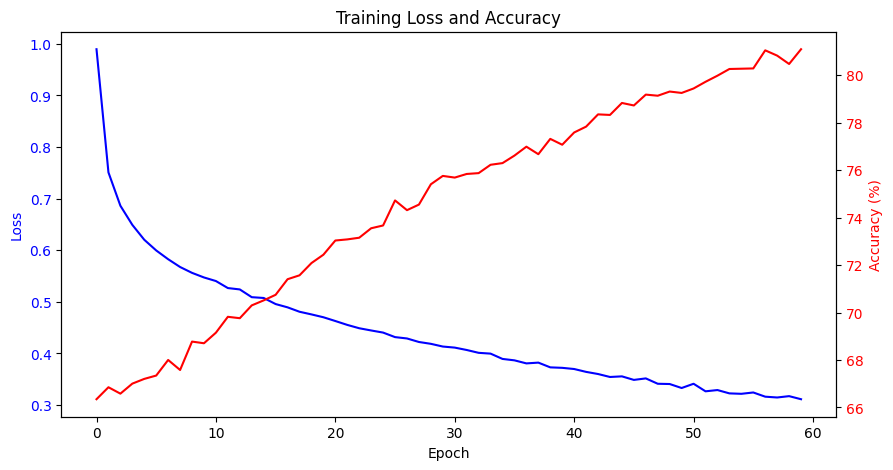

In [74]:
# Now, train on full train + val, test on test
train_val_df = pd.concat([train_df, val_df]).reset_index(drop=True)
train_val_dataset = SkinData(train_val_df, img_dict, img_size=71)
train_val_loader = DataLoader(
    train_val_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

# Train model on full train+val
# model = models.efficientnet_b0(pretrained=True)
# model.classifier = nn.Sequential(
#     nn.Dropout(0.2),
#     nn.Linear(1280, len(classes))
# )
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
num_classes = 7
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
# from torchvision.models import VGG19_Weights
# model = models.vgg19(weights=VGG19_Weights.DEFAULT)
# num_classes = 7
# model.classifier[6] = nn.Linear(4096, num_classes)

# from torchvision import models
# from torchvision.models import Inception_V3_Weights
# weights = Inception_V3_Weights.DEFAULT
# model = models.inception_v3(weights=weights)
# num_classes = 7
# model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

criterion = FocalLoss(gamma=2)
# criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
# criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.0001)

num_epochs = 60
train_losses = []
train_accuracies = []
best_acc = 0.0
best_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    
    for inputs, labels in tqdm(train_val_loader, desc="Training on full train+val"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
    
    train_loss /= len(train_val_loader.dataset)
    train_losses.append(train_loss)
    
    # Compute training accuracy
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in train_val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    train_accuracy = 100 * correct / total
    train_accuracies.append(train_accuracy)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")

# Plot loss and accuracy curves
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='blue')
ax1.plot(train_losses, color='blue', label='Loss')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy (%)', color='red')
ax2.plot(train_accuracies, color='red', label='Accuracy')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Training Loss and Accuracy')
plt.show()

Evaluating on test set: 100%|██████████| 187/187 [00:02<00:00, 70.83it/s]


              precision    recall  f1-score   support

       akiec       0.63      0.32      0.42        53
         bcc       0.59      0.53      0.56        81
         bkl       0.51      0.54      0.53       161
        vasc       1.00      0.05      0.09        21
          nv       0.84      0.94      0.89      1006
         mel       0.51      0.29      0.37       152
          df       0.62      0.45      0.53        22

    accuracy                           0.77      1496
   macro avg       0.67      0.45      0.48      1496
weighted avg       0.75      0.77      0.74      1496



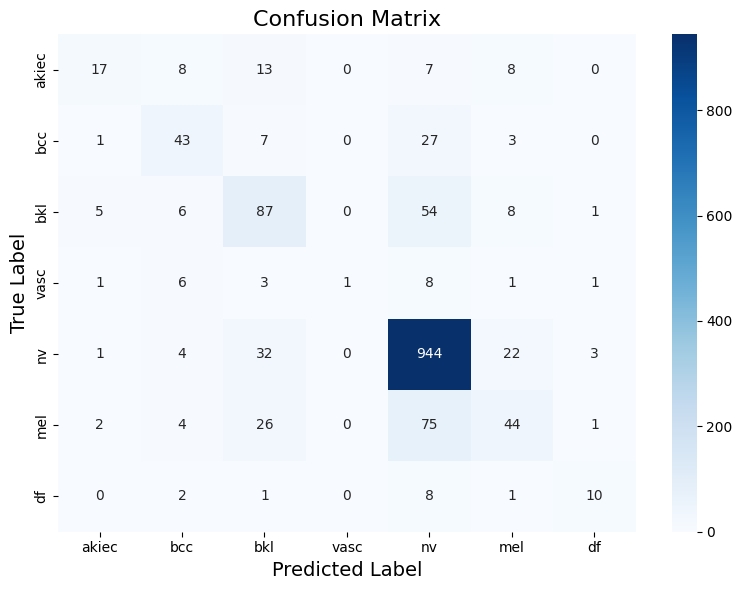

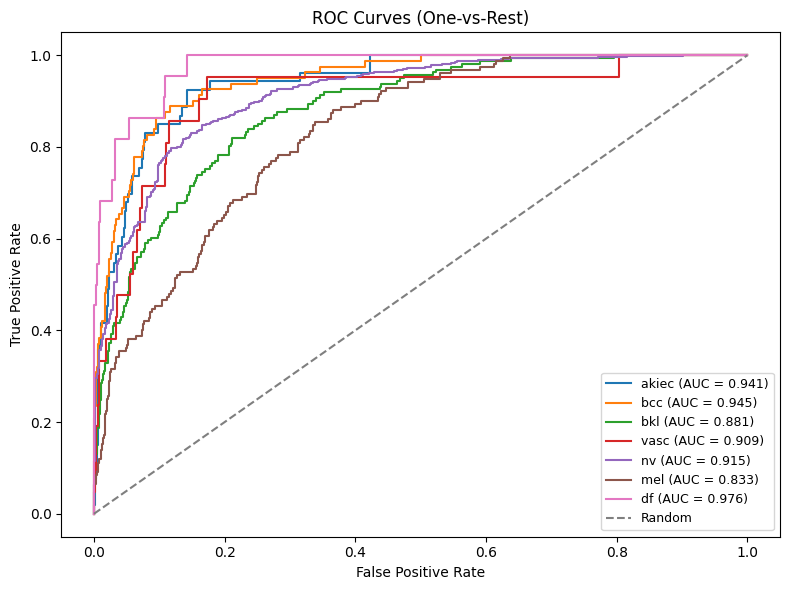

Macro AUC: 0.9142
Micro AUC: 0.9603


In [75]:
from tqdm import tqdm
# Evaluate on test set
# model.load_state_dict(torch.load('best_model.pth'))
model.eval()

y_true_list = []
pred_list = []
y_prob_list = []
# class_names = [
#     "akiec",  # Actinic keratoses
#     "bcc",    # Basal cell carcinoma
#     "bkl",    # Benign keratosis-like lesions
#     "df",     # Dermatofibroma
#     "mel",    # Melanoma
#     "nv",     # Melanocytic nevi
#     "vasc"    # Vascular lesions
# ]

num_classes = len(class_names)

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Evaluating on test set"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1) 
        _, predicted = torch.max(outputs, 1)
        
        y_true_list.append(labels.cpu())
        pred_list.append(predicted.cpu())
        y_prob_list.append(probs.cpu())

# Classification Report
y_true = torch.cat(y_true_list).numpy()
pred = torch.cat(pred_list).numpy()
y_prob = torch.cat(y_prob_list).numpy()

print(classification_report(y_true, pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.tight_layout()
plt.show()

# ROC curve and AUC 
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i],
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ===============================
# Macro & Micro AUC
# ===============================

macro_auc = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
micro_auc = roc_auc_score(y_true_bin, y_prob, average="micro", multi_class="ovr")

print(f"Macro AUC: {macro_auc:.4f}")
print(f"Micro AUC: {micro_auc:.4f}")

In [76]:
print(classification_report(y_true, pred))

              precision    recall  f1-score   support

           0       0.63      0.32      0.42        53
           1       0.59      0.53      0.56        81
           2       0.51      0.54      0.53       161
           3       1.00      0.05      0.09        21
           4       0.84      0.94      0.89      1006
           5       0.51      0.29      0.37       152
           6       0.62      0.45      0.53        22

    accuracy                           0.77      1496
   macro avg       0.67      0.45      0.48      1496
weighted avg       0.75      0.77      0.74      1496

